In [1]:
import roboticstoolbox as rtb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# TODO: Fill in the correct parameters from the UR website

link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
# Create the robot object
my_ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

print(my_ur3e)

DHRobot: My_UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [3]:
# 1. Define Start and End joint configurations
q_start = np.array([0] * 6)           # Robot straight out
q_end   = np.array([4*np.pi] * 6) # Robot folded 90 degrees

# 2. Generate trajectory (50 steps)
traj = rtb.jtraj(q_start, q_end, 50)

# traj.q contains the 50x2 array of joint angles for the path
print("Shape of trajectory:", traj.q.shape)

# 3. Visualize the movement
# This will animate the robot moving through the path
# my_ur3e.plot(traj.q, backend='pyplot')

Shape of trajectory: (50, 6)


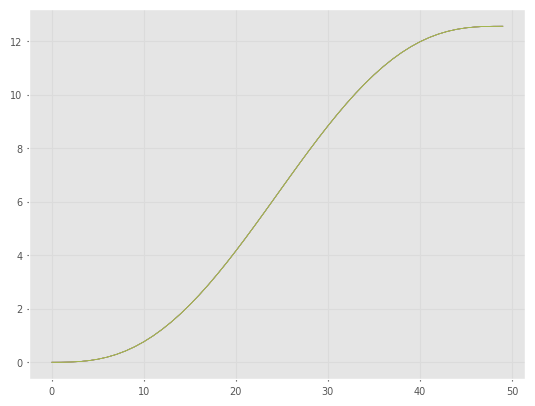

In [4]:
plt.plot(traj.q[:, :])

# Test Kinematic Model

The block below runs the FMU and tries to do some simple movements to indicate that the model works as we expect.

In [5]:
from kinematic_model import KinematicModel

In [6]:
model = KinematicModel()

dt = 0.05
angle_history = []
angle_history.append(model.current_joint_angles.copy())
for i in range(150):
    model.fmi2DoStep(i*dt, dt)
    if i == 10:
        model.fmi2SetCommandedJointAngles([np.pi/4] * 6)
        model.fmi2StartMovement()
    elif i == 40:
        model.fmi2SetCommandedJointAngles([np.pi/2] * 6)
        model.fmi2StartMovement()
    angle_history.append(model.current_joint_angles.copy())
    

In [7]:
np.array(angle_history).shape

(151, 6)

In [8]:
np.array(angle_history)[:, 0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00349066, 0.01047198, 0.02094395,
       0.03490659, 0.05235988, 0.07330383, 0.09773844, 0.12566371,
       0.15707963, 0.19198622, 0.2268928 , 0.26179939, 0.29670597,
       0.33161256, 0.36651914, 0.40142573, 0.43633231, 0.4712389 ,
       0.50614548, 0.54105207, 0.57595865, 0.60737458, 0.63529985,
       0.65973446, 0.68067841, 0.6981317 , 0.71209433, 0.72256631,
       0.72954763, 0.73303829, 0.7400196 , 0.75049158, 0.76445421,
       0.7819075 , 0.80285146, 0.82728607, 0.85521133, 0.88662726,
       0.92153385, 0.95993109, 0.99832833, 1.03672558, 1.07512282,
       1.11352006, 1.15191731, 1.19031455, 1.22871179, 1.26710904,
       1.30550628, 1.34390352, 1.38230077, 1.41720735, 1.44862328,
       1.47654855, 1.50098316, 1.52192711, 1.5393804 , 1.55334303,
       1.56381501, 1.57079633, 1.57428699, 1.57428699, 1.57079

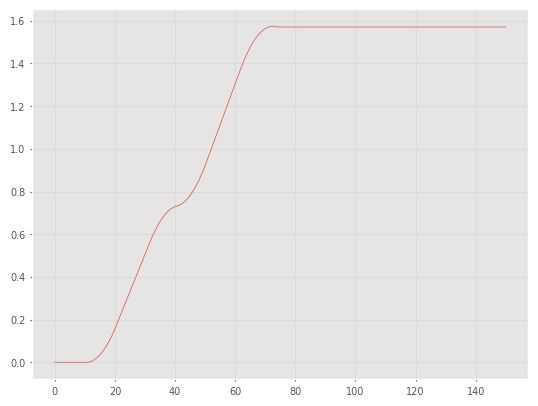

In [9]:
plt.plot(np.array(angle_history)[:, 0])
# plt.plot(np.array(angle_history)[:, 1])